In [3]:
import jax
import jax.numpy as jnp
from jax import value_and_grad, jit
import numpy as np
import matplotlib.pyplot as plt

# Configuración para que las gráficas usen un estilo científico limpio
plt.style.use('default')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'lines.markersize': 6
})

# ==========================================
# CARGA DE DATOS
# ==========================================
# Leemos el archivo específico con el ID del enunciado
# Asumimos que los archivos internos se llaman X, y, t según la estructura de npz
datos = np.load('datos_5303.npz')

# Convertimos los datos a arrays de JAX para poder usarlos en la red
X = jnp.array(datos['X']) # Matriz de señales (36, 256)
y = jnp.array(datos['y']) # Etiquetas de los regímenes (36,)
t = jnp.array(datos['t']) # Vector de tiempo (256,)

print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")
print(f"Forma de t: {t.shape}")

Forma de X: (36, 256)
Forma de y: (36,)
Forma de t: (256,)


# 1. Capa Fourier

Construiremos la matriz $W_1$ utilizando senos y cosenos. Verificaremos que actúa como una transformada de Fourier proyectando una señal sobre esta matriz y comparándola con np.fft. Finalmente, calcularemos la energía media del dataset.

Forma de la matriz W1 (Fourier): (30, 256)


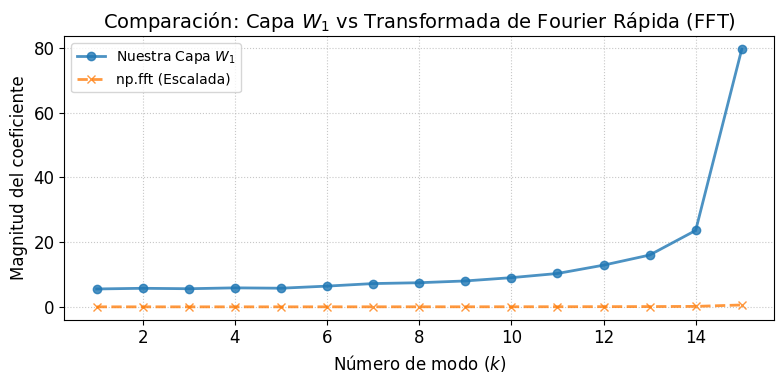

Energía media del dataset: 0.730


In [4]:

def crear_w1_fourier(K, t):
    """
    Construye la matriz W1 con filas de senos y cosenos.
    K: número de frecuencias (15 según el enunciado).
    t: vector de tiempo.
    """
    filas = []
    # Iteramos desde k=1 hasta K para crear las frecuencias
    for k in range(1, K + 1):
        # Agregamos la fila del seno y luego la del coseno
        filas.append(jnp.sin(2 * jnp.pi * k * t))
        filas.append(jnp.cos(2 * jnp.pi * k * t))

    # jnp.vstack apila todas las filas en una sola matriz de forma (2K, 256)
    return jnp.vstack(filas)

# Definimos K=15 como pide el enunciado
K = 15
W1_fourier = crear_w1_fourier(K, t)
print(f"Forma de la matriz W1 (Fourier): {W1_fourier.shape}")

# ------------------------------------------
# Evidencia: Comparación con np.fft
# ------------------------------------------
# Tomamos la primera señal para la prueba
senal_prueba = X[0]

# 1. Proyección manual usando nuestra matriz W1
# Al multiplicar W1 por la señal, obtenemos los coeficientes de Fourier
coeficientes_W1 = jnp.dot(W1_fourier, senal_prueba)
# Calculamos la magnitud combinando cada par de seno/coseno (a^2 + b^2)
magnitud_W1 = jnp.sqrt(coeficientes_W1[0::2]**2 + coeficientes_W1[1::2]**2)

# 2. Transformada usando numpy (np.fft)
fft_numpy = np.fft.fft(senal_prueba)
# Tomamos las frecuencias positivas, ignorando la frecuencia cero (continua)
# y limitamos hasta K para poder comparar manzanas con manzanas.
magnitud_fft = np.abs(fft_numpy)[1:K+1]

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, K+1), magnitud_W1, marker='o', label='Nuestra Capa $W_1$', alpha=0.8)
# Escalamos la FFT de numpy por un factor normalizador (2/N) para que las amplitudes coincidan
ax.plot(range(1, K+1), magnitud_fft * (2 / len(t)), marker='x', linestyle='--', label='np.fft (Escalada)', alpha=0.8)

ax.set_title("Comparación: Capa $W_1$ vs Transformada de Fourier Rápida (FFT)")
ax.set_xlabel(r"Número de modo ($k$)")
ax.set_ylabel(r"Magnitud del coeficiente")
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------
# Reporte de energía media
# ------------------------------------------
# Calculamos la energía media del dataset como (X**2).mean()
energia_media = (X**2).mean()
print(f"Energía media del dataset: {energia_media:.3f}")